In [1]:
import torch
import cv2
import numpy as np
import gymnasium as gym

# Check PyTorch & Hardware Acceleration
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"🚀 PyTorch is using: {device}")

# Create a dummy "Grid" using NumPy/OpenCV
grid = np.zeros((100, 100, 3), dtype=np.uint8)
cv2.rectangle(grid, (20, 20), (40, 40), (0, 255, 0), -1) # Draw a green square

# Convert to PyTorch Tensor (Simulating CNN input)
# CNNs expect (Batch, Channels, Height, Width)
tensor_input = torch.from_numpy(grid).permute(2, 0, 1).float().unsqueeze(0).to(device)
print(f"📦 Grid shape for CNN: {tensor_input.shape}")

print("✅ Setup complete and verified!")

🚀 PyTorch is using: mps
📦 Grid shape for CNN: torch.Size([1, 3, 100, 100])
✅ Setup complete and verified!


In [3]:
import sys
from pathlib import Path

import gymnasium as gym
import numpy as np

# Parent of this `notebooks/` folder is the `chase` project root (contains `env/`).
_chase_root = Path.cwd()
if _chase_root.name == "notebooks":
    _chase_root = _chase_root.parent
sys.path.insert(0, str(_chase_root.resolve()))

import env  # noqa: F401 — side effect: registers `Chase-v0`

# n must divide 512; default 16 → 32×32 px per cell
chase_env = gym.make(
    "Chase-v0",
    n=16,
    render_mode="rgb_array",
    max_episode_steps=256,
)
obs, info = chase_env.reset(seed=42)
print("obs shape:", obs.shape, "dtype:", obs.dtype)
print("info:", info)
print("actions: 0=up, 1=down, 2=left, 3=right")

obs shape: (512, 512, 3) dtype: uint8
info: {'agent': (10, 7), 'target_center': (2, 11), 'target_top_left': (1, 10)}
actions: 0=up, 1=down, 2=left, 3=right


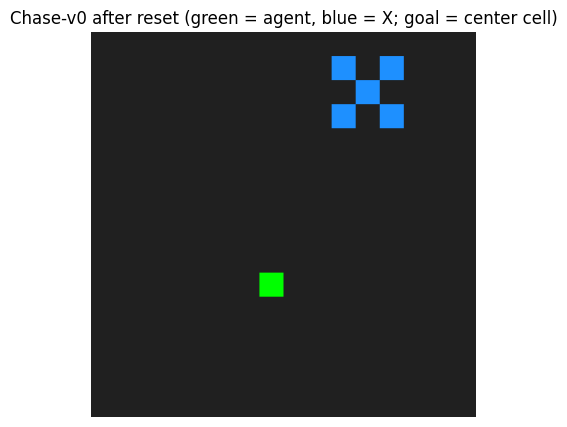

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(obs)
ax.set_title("Chase-v0 after reset (green = agent, blue = X; goal = center cell)")
ax.axis("off")
plt.show()

cumulative reward: -0.4


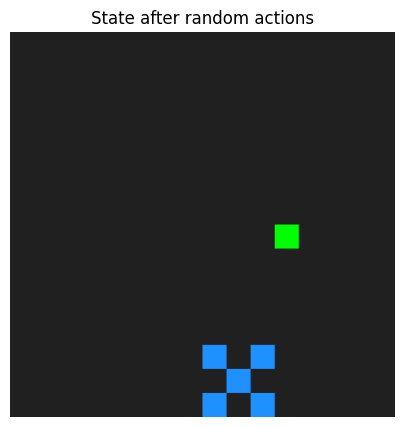

In [6]:
# Short random rollout — stop early if the episode ends
obs, info = chase_env.reset(seed=7)
total_r = 0.0
for t in range(40):
    action = chase_env.action_space.sample()
    obs, reward, terminated, truncated, info = chase_env.step(action)
    total_r += float(reward)
    if terminated or truncated:
        print(f"stopped at t={t} reward={reward} terminated={terminated} truncated={truncated}")
        break
print("cumulative reward:", round(total_r, 3))

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(obs)
ax.set_title("State after random actions")
ax.axis("off")
plt.show()

finished in 3 steps | reward=1.0 terminated=True truncated=False


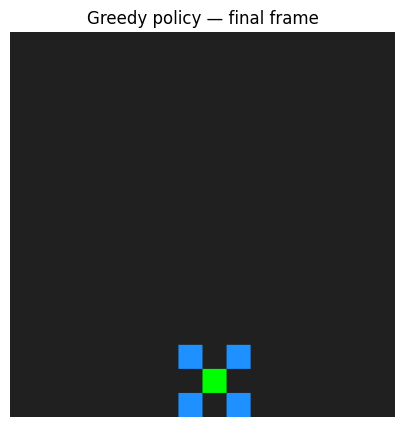

In [7]:
# Greedy policy toward the goal (center of the 3×3 X) — usually reaches it quickly
def greedy_action(agent_row: int, agent_col: int, goal_row: int, goal_col: int) -> int:
    if agent_row > goal_row:
        return 0  # up
    if agent_row < goal_row:
        return 1  # down
    if agent_col > goal_col:
        return 2  # left
    if agent_col < goal_col:
        return 3  # right
    return 0


obs, info = chase_env.reset(seed=99)
gr, gc = info["target_center"]
steps = 0
while steps < 200:
    ar, ac = info["agent"]
    a = greedy_action(ar, ac, gr, gc)
    obs, reward, terminated, truncated, info = chase_env.step(a)
    steps += 1
    if terminated or truncated:
        print(f"finished in {steps} steps | reward={reward} terminated={terminated} truncated={truncated}")
        break

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(obs)
ax.set_title("Greedy policy — final frame")
ax.axis("off")
plt.show()

In [ ]:
# Manual moves: a scripted path with a short pause between frames
# (Run cell 1 first so `chase_env` exists.)
import time

import matplotlib.pyplot as plt
from IPython.display import clear_output

obs, info = chase_env.reset(seed=2026)
action_names = {0: "up", 1: "down", 2: "left", 3: "right"}
# Example path: right, right, down, left, up
sequence = [3, 3, 1, 2, 0]
delay_s = 0.45

for i, a in enumerate(sequence):
    obs, reward, terminated, truncated, info = chase_env.step(a)
    clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(obs)
    ax.set_title(
        f"Move {i + 1}/{len(sequence)}: {action_names[a]} (action={a}) | agent {info['agent']}"
    )
    ax.axis("off")
    plt.show()
    time.sleep(delay_s)
    if terminated or truncated:
        print(
            f"Episode ended early: terminated={terminated} truncated={truncated} reward={reward}"
        )
        break
else:
    print("Done. Final agent:", info["agent"])